In [1]:
install.packages("sqldf")
library(sqldf)

print("Loading NorthStar dataset...")

hubs <- read.csv("hubs.csv")
customers <- read.csv("customers.csv")
drivers <- read.csv("drivers.csv")
vehicles <- read.csv("vehicles.csv")
orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
incidents <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")
app_events <- read.csv("app_events.csv")

print("All files loaded successfully")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



[1] "Loading NorthStar dataset..."
[1] "All files loaded successfully"


In [2]:
q1 <- sqldf("
  SELECT delivery_status,
         COUNT(*) AS total_deliveries
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")

print(q1)



  delivery_status total_deliveries
1          OnTime              616
2         Delayed              202
3          Failed              132


In [3]:
q2 <- sqldf("
  SELECT o.service_type,
         COUNT(*) AS failed_count
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  WHERE d.delivery_status = 'Failed'
  GROUP BY o.service_type
  ORDER BY failed_count DESC
")

print(q2)



  service_type failed_count
1    Passenger           38
2       Retail           28
3       Parcel           25
4     Business           25
5      Medical           16


In [4]:
q3 <- sqldf("
  SELECT o.pickup_zone,
         COUNT(*) AS total_orders,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failed_deliveries DESC
")

print(q3)


   pickup_zone total_orders failed_deliveries avg_customer_rating
1    RiverSide           66                14                3.80
2         EAST           78                11                3.86
3          Ctr           64                11                3.43
4      Central           55                11                3.59
5      CENTRAL           55                11                3.64
6        South           83                10                3.99
7        north           52                 8                3.94
8         East           78                 8                3.96
9      Airport           67                 8                3.86
10        West           51                 7                3.94
11        WEST           63                 7                3.86
12       North           37                 7                3.84
13       NORTH           46                 7                3.89
14       SOUTH           56                 4                4.14
15   River

In [5]:
q4 <- sqldf("
  SELECT
    CASE
      WHEN dr.years_experience < 3 THEN 'Junior (0-2 years)'
      WHEN dr.years_experience < 7 THEN 'Mid-level (3-6 years)'
      ELSE 'Senior (7+ years)'
    END AS experience_group,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(AVG(dr.driver_rating), 2) AS avg_driver_rating
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY experience_group
  ORDER BY failed_deliveries DESC
")

print(q4)

       experience_group total_deliveries failed_deliveries avg_driver_rating
1     Senior (7+ years)              614                97              4.19
2 Mid-level (3-6 years)              232                26              4.03
3    Junior (0-2 years)              104                 9              4.31


In [6]:
q5 <- sqldf("
  SELECT h.hub_name,
         h.zone,
         COUNT(c.complaint_id) AS total_complaints,
         ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  JOIN orders o ON d.order_id = o.order_id
  JOIN complaints c ON c.order_id = o.order_id
  GROUP BY h.hub_name, h.zone
  ORDER BY total_complaints DESC
")

print(q5)

        hub_name      zone total_complaints avg_resolution_days
1  Midtown Relay   Central               35                 8.1
2      East Dock      East               33                 7.9
3  Riverside Hub Riverside               33                 6.5
4 North Exchange     North               32                 7.9
5   Central Core   Central               30                 9.4
6      West Gate      West               28                 7.2
7    Airport Hub   Airport               23                 9.1
8     South Link     South               18                 7.5


In [7]:
q6 <- sqldf("
  SELECT priority_level,
         COUNT(*) AS total_orders,
         ROUND(AVG(order_value), 2) AS avg_order_value,
         ROUND(SUM(order_value), 2) AS total_order_value
  FROM orders
  GROUP BY priority_level
  ORDER BY avg_order_value DESC
")

print(q6)

  priority_level total_orders avg_order_value total_order_value
1           High          308           95.66          29464.42
2         Medium          503           90.18          45361.87
3       Critical           91           89.38           8133.99
4            Low          348           88.66          30852.87


In [8]:
library(dplyr)
library(ggplot2)
library(tidyr)

drivers <- drivers %>%
  mutate(
    training_score = ifelse(
      is.na(training_score),
      median(training_score, na.rm = TRUE),
      training_score
    )
  )

customers <- customers %>%
  mutate(
    loyalty_score = ifelse(
      is.na(loyalty_score),
      median(loyalty_score, na.rm = TRUE),
      loyalty_score
    ),
    preferred_channel = ifelse(
      is.na(preferred_channel),
      "Unknown",
      preferred_channel
    )
  )

deliveries <- deliveries %>%
  mutate(
    customer_rating_post_delivery = ifelse(
      is.na(customer_rating_post_delivery),
      median(customer_rating_post_delivery, na.rm = TRUE),
      customer_rating_post_delivery
    )
  )

complaints <- complaints %>%
  mutate(
    compensation_amount = ifelse(
      is.na(compensation_amount),
      0,
      compensation_amount
    )
  )

vehicles <- vehicles %>%
  mutate(
    battery_health_pct = ifelse(
      is.na(battery_health_pct),
      median(battery_health_pct, na.rm = TRUE),
      battery_health_pct
    )
  )

cat("Drivers missing:", sum(is.na(drivers)), "\n")
cat("Customers missing:", sum(is.na(customers)), "\n")
cat("Deliveries missing:", sum(is.na(deliveries)), "\n")
cat("Complaints missing:", sum(is.na(complaints)), "\n")
cat("Vehicles missing:", sum(is.na(vehicles)), "\n")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Drivers missing: 0 
Customers missing: 0 
Deliveries missing: 0 
Complaints missing: 0 
Vehicles missing: 0 


In [9]:
delivery_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    total_deliveries = n(),
    percentage = round(n() / nrow(deliveries) * 100, 1),
    avg_customer_rating = round(mean(customer_rating_post_delivery), 2),
    avg_delivery_cost = round(mean(fuel_or_charge_cost), 2)
  )

print(delivery_summary)

# A tibble: 3 × 5
  delivery_status total_deliveries percentage avg_customer_rating
  <chr>                      <int>      <dbl>               <dbl>
1 Delayed                      202       21.3                3.14
2 Failed                       132       13.9                3.06
3 OnTime                       616       64.8                4.28
# ℹ 1 more variable: avg_delivery_cost <dbl>


In [10]:
drv_perf <- deliveries %>%
  inner_join(drivers, by = "driver_id") %>%
  group_by(driver_id, driver_rating) %>%
  summarise(
    total_deliveries = n(),
    failed_deliveries = sum(delivery_status == "Failed"),
    fail_rate = round(failed_deliveries / total_deliveries * 100, 1),
    .groups = "drop"
  )

cor_result <- cor(
  drv_perf$driver_rating,
  drv_perf$fail_rate,
  use = "complete.obs"
)

cat("Correlation:", round(cor_result, 3))

Correlation: -0.236

In [11]:
complaint_stats <- complaints %>%
  group_by(severity) %>%
  summarise(
    total_complaints = n(),
    avg_resolution_days = round(mean(resolution_days, na.rm = TRUE), 1),
    avg_compensation = round(mean(compensation_amount, na.rm = TRUE), 2),
    escalated_cases = sum(status == "Escalated")
  ) %>%
  arrange(desc(avg_compensation))

print(complaint_stats)

# A tibble: 3 × 5
  severity total_complaints avg_resolution_days avg_compensation escalated_cases
  <chr>               <int>               <dbl>            <dbl>           <int>
1 High                   77                13.1            34.3                8
2 Medium                172                 6.2            16.8               21
3 Low                    71                 6.6             8.93               9


In [12]:
battery_stats <- vehicles %>%
  group_by(maintenance_status) %>%
  summarise(
    total_vehicles = n(),
    avg_battery = round(mean(battery_health_pct), 1),
    min_battery = min(battery_health_pct),
    max_battery = max(battery_health_pct)
  )

print(battery_stats)

# A tibble: 3 × 5
  maintenance_status total_vehicles avg_battery min_battery max_battery
  <chr>                       <int>       <dbl>       <dbl>       <dbl>
1 Active                         67        76.7        42           100
2 InRepair                       36        76.6        47.6         100
3 Scheduled                      17        77.7        65.5         100


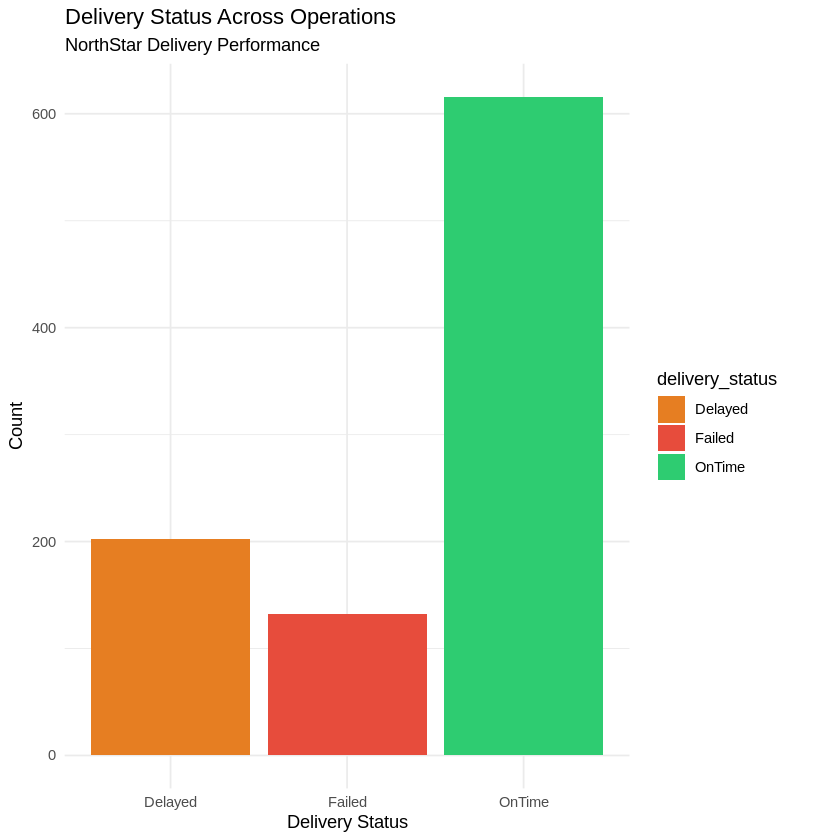

In [13]:
ggplot(deliveries,
       aes(x = delivery_status,
           fill = delivery_status)) +

  geom_bar() +

  scale_fill_manual(values = c(
    "OnTime" = "#2ecc71",
    "Delayed" = "#e67e22",
    "Failed" = "#e74c3c"
  )) +

  labs(
    title = "Delivery Status Across Operations",
    subtitle = "NorthStar Delivery Performance",
    x = "Delivery Status",
    y = "Count"
  ) +

  theme_minimal()

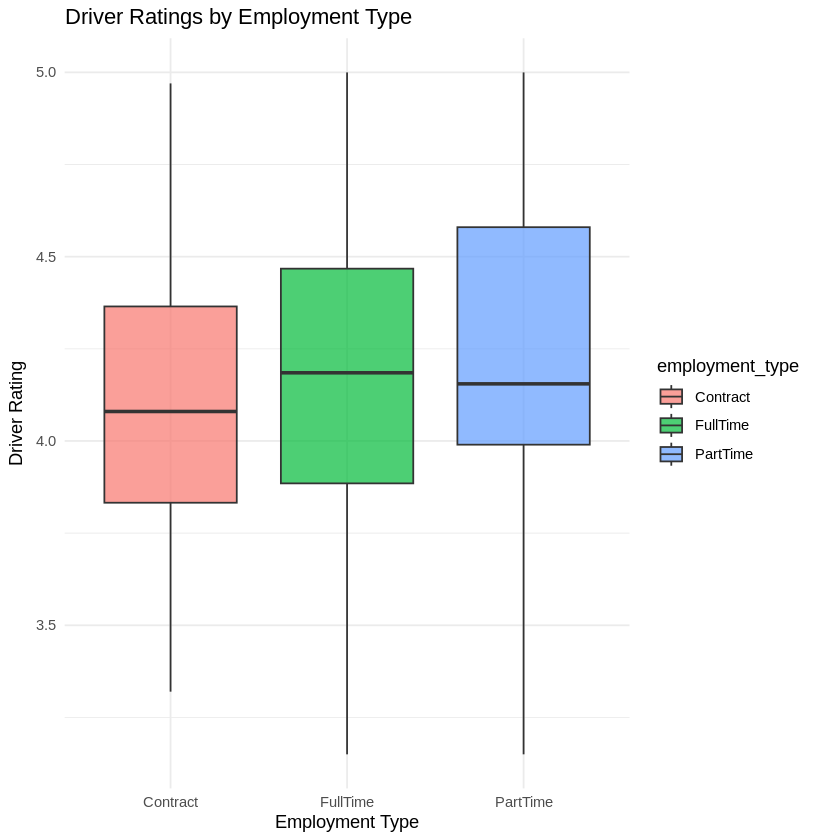

In [14]:
ggplot(drivers,
       aes(x = employment_type,
           y = driver_rating,
           fill = employment_type)) +

  geom_boxplot(alpha = 0.7) +

  labs(
    title = "Driver Ratings by Employment Type",
    x = "Employment Type",
    y = "Driver Rating"
  ) +

  theme_minimal()

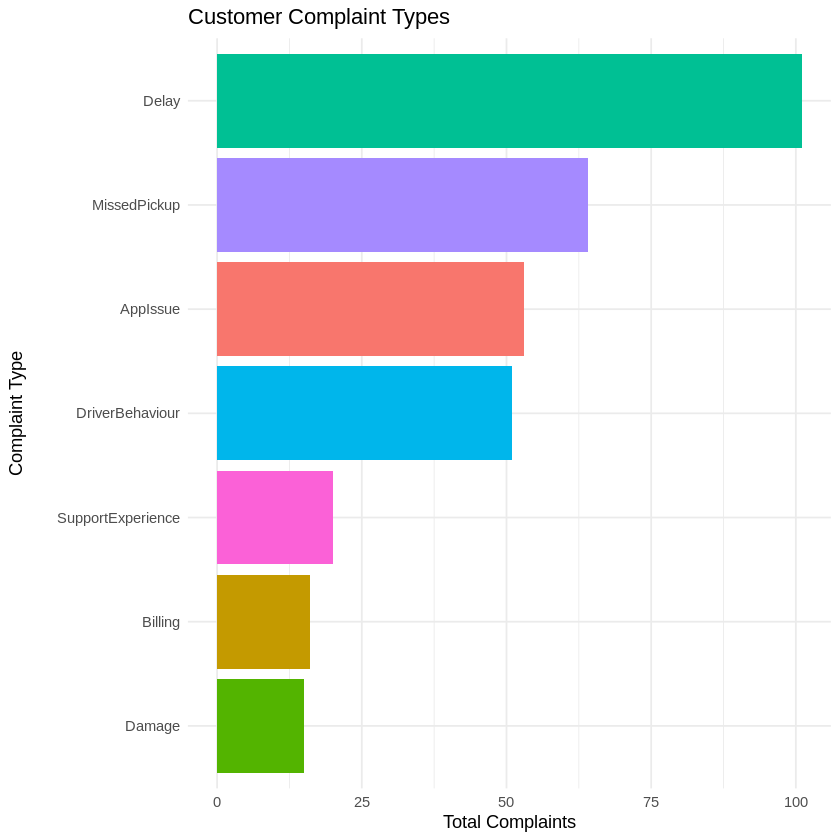

In [15]:
complaints %>%
  group_by(complaint_type) %>%
  summarise(total = n()) %>%

  ggplot(aes(
    x = reorder(complaint_type, total),
    y = total,
    fill = complaint_type
  )) +

  geom_col(show.legend = FALSE) +

  coord_flip() +

  labs(
    title = "Customer Complaint Types",
    x = "Complaint Type",
    y = "Total Complaints"
  ) +

  theme_minimal()

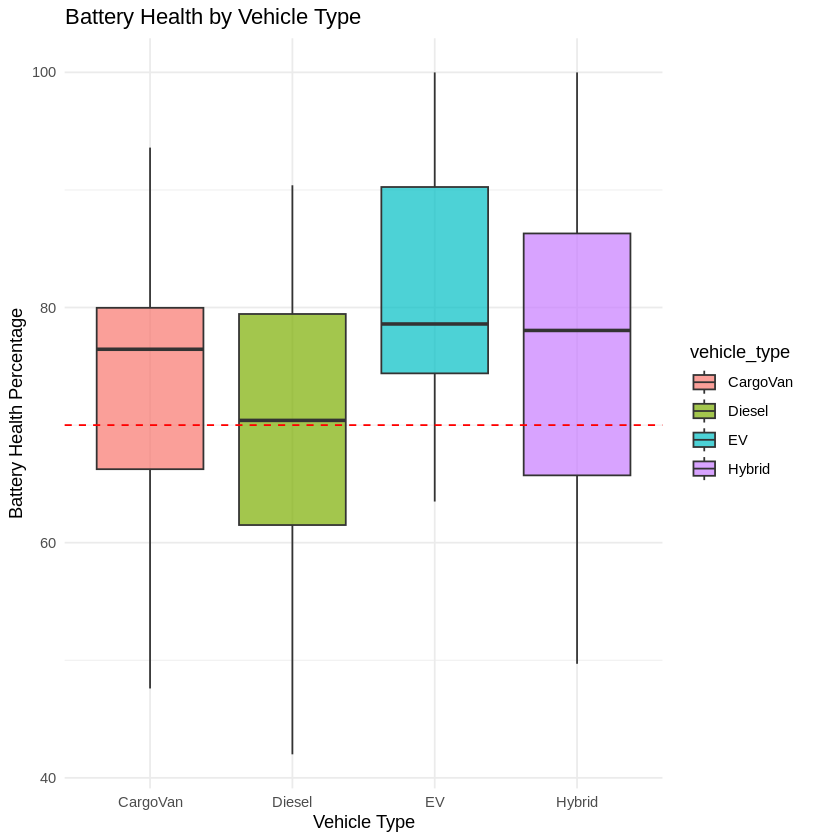

In [16]:
ggplot(vehicles,
       aes(x = vehicle_type,
           y = battery_health_pct,
           fill = vehicle_type)) +

  geom_boxplot(alpha = 0.7) +

  geom_hline(
    yintercept = 70,
    linetype = "dashed",
    color = "red"
  ) +

  labs(
    title = "Battery Health by Vehicle Type",
    x = "Vehicle Type",
    y = "Battery Health Percentage"
  ) +

  theme_minimal()

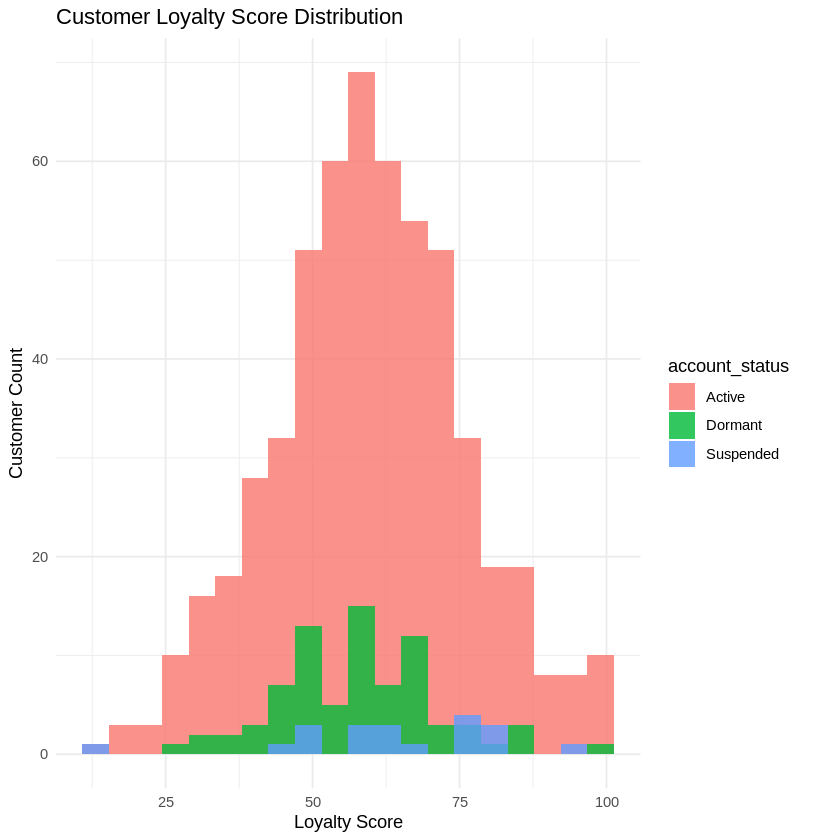

In [17]:
ggplot(customers,
       aes(x = loyalty_score,
           fill = account_status)) +

  geom_histogram(
    bins = 20,
    alpha = 0.8,
    position = "identity"
  ) +

  labs(
    title = "Customer Loyalty Score Distribution",
    x = "Loyalty Score",
    y = "Customer Count"
  ) +

  theme_minimal()


# New Section